In [27]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

## 1.Analsisi Karakteristik Dataset

In [28]:
df = pd.read_csv('../1.FIFA Transfer Market Analytics/fifa_player_performance_market_value.csv')
df.head()

,player_id,player_name,age,nationality,club,position,overall_rating,potential_rating,matches_played,goals,assists,minutes_played,market_value_million_eur,contract_years_left,injury_prone,transfer_risk_level
0,1,Player_1,23,Germany,Liverpool,ST,65,87,8,6,14,2976,122.51,3,No,Low
1,2,Player_2,36,England,FC Barcelona,ST,90,76,19,3,18,2609,88.47,5,No,High
2,3,Player_3,31,France,Juventus,RB,75,91,34,12,15,1158,20.24,3,No,Medium
3,4,Player_4,27,Portugal,Manchester City,LW,90,86,35,18,13,145,164.29,0,Yes,Medium
4,5,Player_5,24,Brazil,Liverpool,CDM,84,96,41,6,6,2226,121.34,4,No,Low


In [29]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2800 entries, 0 to 2799
Data columns (total 16 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   player_id                 2800 non-null   int64  
 1   player_name               2800 non-null   object 
 2   age                       2800 non-null   int64  
 3   nationality               2800 non-null   object 
 4   club                      2800 non-null   object 
 5   position                  2800 non-null   object 
 6   overall_rating            2800 non-null   int64  
 7   potential_rating          2800 non-null   int64  
 8   matches_played            2800 non-null   int64  
 9   goals                     2800 non-null   int64  
 10  assists                   2800 non-null   int64  
 11  minutes_played            2800 non-null   int64  
 12  market_value_million_eur  2800 non-null   float64
 13  contract_years_left       2800 non-null   int64  
 14  injury_p

In [30]:
df.shape

(2800, 16)

In [31]:
df.isnull().sum()

player_id                   0
player_name                 0
age                         0
nationality                 0
club                        0
position                    0
overall_rating              0
potential_rating            0
matches_played              0
goals                       0
assists                     0
minutes_played              0
market_value_million_eur    0
contract_years_left         0
injury_prone                0
transfer_risk_level         0
dtype: int64

In [32]:
df.duplicated().sum()

np.int64(0)

In [33]:
df = df.drop(columns=['player_id','player_name'])
df.shape

(2800, 14)

In [34]:
for col in df.columns:
    print(f"Nilai unik untuk kolom '{col}':")
    print(df[col].unique())
    print("-" * 40)

Nilai unik untuk kolom 'age':
[23 36 31 27 24 37 35 39 20 19 38 18 28 22 17 33 26 32 21 25 34 30 29]
----------------------------------------
Nilai unik untuk kolom 'nationality':
['Germany' 'England' 'France' 'Portugal' 'Brazil' 'Argentina'
 'Netherlands' 'Spain']
----------------------------------------
Nilai unik untuk kolom 'club':
['Liverpool' 'FC Barcelona' 'Juventus' 'Manchester City' 'Bayern Munich'
 'PSG' 'Real Madrid']
----------------------------------------
Nilai unik untuk kolom 'position':
['ST' 'RB' 'LW' 'CDM' 'CM' 'GK' 'LB' 'RW' 'CB']
----------------------------------------
Nilai unik untuk kolom 'overall_rating':
[65 90 75 84 92 72 69 83 62 93 87 78 82 91 64 66 81 89 77 67 74 63 85 60
 79 80 71 68 73 61 70 88 76 86 94]
----------------------------------------
Nilai unik untuk kolom 'potential_rating':
[87 76 91 86 96 66 97 90 92 83 69 84 94 72 81 65 67 95 68 80 77 88 98 89
 82 79 70 78 71 73 74 85 93 75]
----------------------------------------
Nilai unik untuk kolom 

In [35]:
feature_numerik = ["age","overall_rating", "potential_rating", "matches_played", "goals", "assists", "minutes_played", "market_value_million_eur", "contract_years_left"]
feature_categori = ["nationality","club","position","injury_prone"]
feature_target = "transfer_risk_level"

## 2.Analisi Unvariat

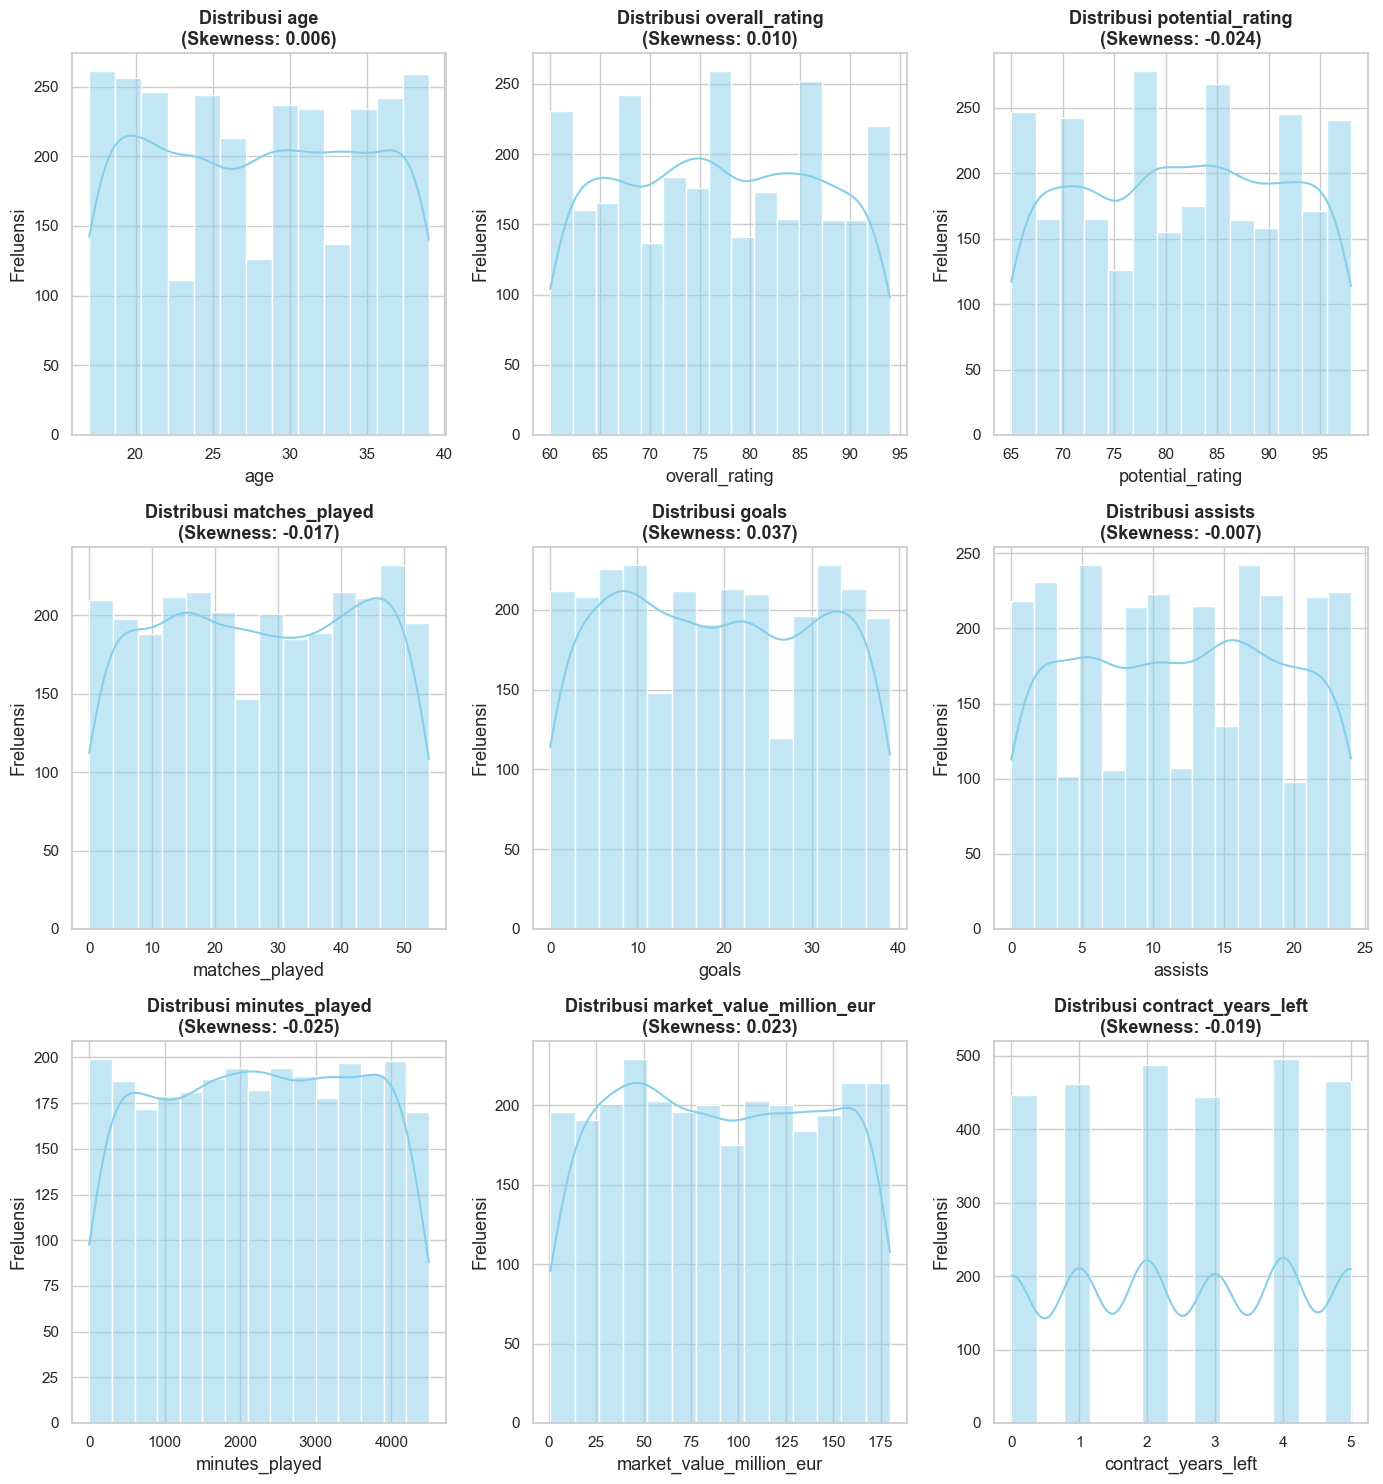

In [42]:
sns.set_theme(style='whitegrid')
fig,axes = plt.subplots(3,3,figsize=(14,15))
axes = axes.flatten()

for i,feature in enumerate(feature_numerik):
    feat_skew = df[feature].skew()
    sns.histplot(df[feature],ax=axes[i],kde=True,color='skyblue',bins='auto')
    axes[i].set_title(f'Distribusi {feature}\n(Skewness: {feat_skew:.3f})',fontsize=13,fontweight='bold')
    axes[i].set_xlabel(feature,fontsize=13)
    axes[i].set_ylabel('Freluensi',fontsize=13)
plt.tight_layout()
plt.show()